# TileDB-SOMA Object Operations: Examples

This notebook contains example commands and common usage patterns for opening, inspecting, interacting and working with TileDB-SOMA objects.
This contains only some relevant examples and is not exhaustive.

Use conda env `tiledbsoma` (`/opt/mamba/envs/tiledbsoma/`) on scds-c server.

In [1]:
import tiledbsoma as soma
import tiledbsoma.io
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import s3fs
import os

## Experiments

### Accessing TileDB-SOMA Experiment

Example experiment: `s3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt`

In [16]:
expt_uri = "s3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt"
expt = soma.Experiment.open(expt_uri)
print(expt)

<Experiment 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt' (open for 'r') (2 items)
    'ms': 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/ms' (unopened)
    'obs': 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/obs' (unopened)>


### Access various components of the dataset

**Access `obs` (SOMA dataframe with cell level annotations)**

In [17]:
print(expt.obs)
expt.obs.read().concat().to_pandas()

<DataFrame 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/obs' (open for 'r')>


,soma_joinid,obs_id,orig.ident,nFeature_RNA,nCount_RNA,percent.mt,percent.ribo,percent.hemoglobin,S_score,G2M_score,...,popv_prediction_depth,popv_prediction_onclass_relative_depth,popv_parent_ontology_name,popv_parent_ontology_id,cancerFinder_score,cancerFinder_call,cancerFinder_call_healthy_samples_censored,study_institution,catalog_study_id,donor_treatment_mesh_id
0,0,K562_GSM1980077,K562,5288.0,690894.0,11.777060,3.749490,0.099002,61.443643,52.549784,...,5,-1,erythroid progenitor cell,CL:0000038,0.998671,Tumor,Tumor,None,None,None
1,1,K562_GSM1980078,K562,3678.0,441474.0,13.699108,3.549473,0.164902,43.399690,64.752285,...,5,-1,hematopoietic precursor cell,CL:0008001,0.995290,Tumor,Tumor,None,None,None
2,2,K562_GSM1980079,K562,4056.0,1310139.0,10.594372,4.497691,0.305235,-66.608527,-59.887061,...,4,0,hematopoietic precursor cell,CL:0008001,0.979533,Tumor,Tumor,None,None,None
3,3,K562_GSM1980080,K562,4589.0,1921304.0,10.378992,3.829430,0.356060,-74.980930,-105.904329,...,5,-1,progenitor cell,CL:0011026,0.995342,Tumor,Tumor,None,None,None
4,4,K562_GSM1980082,K562,3509.0,1376365.0,13.450429,3.304792,0.377226,-61.651628,-37.041270,...,5,-1,hematopoietic precursor cell,CL:0008001,0.984695,Tumor,Tumor,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,2031,OX1705_GSM2509122,OX1705,5805.0,1986606.0,9.244661,9.639556,0.000000,31.501874,-50.146063,...,4,0,hematopoietic stem cell,CL:0000037,0.948704,Tumor,Tumor,None,None,None
2032,2032,OX1705_GSM2509123,OX1705,4955.0,1869256.0,11.906074,7.911971,0.000053,135.464529,-49.002157,...,4,0,hematopoietic stem cell,CL:0000037,0.884899,Tumor,Tumor,None,None,None
2033,2033,OX1705_GSM2509124,OX1705,5705.0,2326327.0,9.935705,16.355482,0.000000,-84.399503,-68.347393,...,4,0,hematopoietic stem cell,CL:0000037,0.949036,Tumor,Tumor,None,None,None
2034,2034,OX1705_GSM2509125,OX1705,4862.0,1436412.0,7.186448,9.320237,0.000000,-46.362971,-41.904315,...,4,0,hematopoietic stem cell,CL:0000037,0.865040,Tumor,Tumor,None,None,None


**Access the SOMA Measurement containing the RNA counts data**

In [18]:
expt.ms["RNA"]

<Measurement 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/ms/RNA' (open for 'r') (6 items)
    'X': 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/ms/RNA/X' (unopened)
    'obsm': 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/ms/RNA/obsm' (unopened)
    'obsp': 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/ms/RNA/obsp' (unopened)
    'uns': 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/ms/RNA/uns' (unopened)
    'var': 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/ms/RNA/var' (unopened)
    'varm': 's3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt/ms/RNA/varm' (unopened)>


**Access `var` (SOMA dataframe with the feature-level annotations)**

In [19]:
expt.ms["RNA"].var.read().concat().to_pandas()

,soma_joinid,var_id,gene_ids,feature_types,mt,ribo,hemoglobin,gene_symbols,gene_symbols_2024A,genome,highly_variable,means,dispersions,dispersions_norm,mean,std
0,0,TSPAN6,ENSG00000000003,Gene Expression,False,False,False,TSPAN6,TSPAN6,GRCh38,True,4.958227e-02,1.729043,0.996466,0.020592,0.168125
1,1,TNMD,ENSG00000000005,Gene Expression,False,False,False,TNMD,TNMD,GRCh38,False,1.000000e-12,NaN,0.000000,0.000000,1.000000
2,2,DPM1,ENSG00000000419,Gene Expression,False,False,False,DPM1,DPM1,GRCh38,False,3.718615e-01,1.462034,-1.026260,0.201106,0.472227
3,3,SCYL3,ENSG00000000457,Gene Expression,False,False,False,SCYL3,SCYL3,GRCh38,True,1.780046e-01,2.156234,1.160082,0.069409,0.318505
4,4,C1orf112,ENSG00000000460,Gene Expression,False,False,False,C1orf112,C1orf112,GRCh38,True,1.203737e-01,1.574168,0.937148,0.055430,0.266165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36517,36517,CRIPAK,ENSG00000288380,Gene Expression,False,False,False,CRIPAK,NA,GRCh38,True,5.881637e-02,2.104976,1.140449,0.020208,0.184191
36518,36518,AL109627.1,ENSG00000288398,Gene Expression,False,False,False,AL109627.1,ENSG00000288398,GRCh38,True,4.192125e-02,1.382822,0.863862,0.021468,0.148799
36519,36519,AC024558.2,ENSG00000288436,Gene Expression,False,False,False,AC024558.2,NA,GRCh38,False,2.071631e-06,-5.468431,-1.760189,0.000002,0.000093
36520,36520,AL512357.2,ENSG00000288459,Gene Expression,False,False,False,AL512357.2,ENSG00000288459,GRCh38,False,4.285502e-06,-4.938561,-1.557247,0.000004,0.000175


### Create anndata object/h5ad file from TileDB-SOMA experiment

**Create anndata object from TileDB-SOMA experiment**

In [20]:
experiment_path = "s3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt"
expt = soma.Experiment.open(experiment_path)

adata_from_expt = tiledbsoma.io.to_anndata(
    expt,
    measurement_name="RNA"
)

adata_from_expt

AnnData object with n_obs × n_vars = 2036 × 36522
    obs: 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_id', 'author_cell_type_cell_ontology_name', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sample_preservation

**Create anndata h5ad file from TileDB-SOMA experiment**

`tiledbsoma.io.to_h5ad()` writes the file directly, but it fails when an `obs`/`var` column is entirely `None`/`NaN` — h5py can't serialize an all-null object column as an HDF5 string, raising:

```
TypeError: Can't implicitly convert non-string objects to strings
```

To avoid this, build the AnnData first, coerce object (string) columns to real strings (turning `None` into `""`), then write the h5ad.

In [21]:
experiment_path = "s3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt"
batch = experiment_path.rstrip("/").split("/")[-3]
dataset = experiment_path.rstrip("/").split("/")[-2]
h5ad_name = f"{batch}_{dataset}_anndata.h5ad"
h5ad_path = f"/tmp/{h5ad_name}"

expt = soma.Experiment.open(experiment_path)

# Build the AnnData, then coerce object columns to strings so all-None columns
# (e.g. study_institution) don't break the h5ad write.
adata = tiledbsoma.io.to_anndata(expt, measurement_name="RNA")

def stringify_object_columns(df):
    """Cast object-dtype columns to str, turning None/NaN into empty strings."""
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype("string").fillna("").astype(str)

stringify_object_columns(adata.obs)
stringify_object_columns(adata.var)

adata.write_h5ad(h5ad_path)
print(f"Anndata from {experiment_path} is written to {h5ad_path}")

Anndata from s3://rancho-scds-collections/tiledb-experiments/batch14/GSE76312/tiledbsoma_expt is written to /tmp/batch14_GSE76312_anndata.h5ad


### Slicing and Filtering Experiments

**Querying for cells with nFeature_RNA > 1000 and genes that are highly_variable**

The query result object (`query`) allows to inspect the query result and selectively access the data instead of loading the entire dataset

In [22]:
query = soma.ExperimentAxisQuery(
    experiment=expt,
    measurement_name="RNA",
    obs_query=soma.AxisQuery(
        value_filter="nFeature_RNA > 1000",
    ),
    var_query=soma.AxisQuery(
        value_filter="highly_variable == True",
    ),
)

**See how many cells and genes are returned with the above query**

In [23]:

(query.n_obs, query.n_vars)

(2036, 9749)

**Access the DataFrame containing the annotations for all cells returned by the above query**

In [24]:
query.obs().concat().to_pandas()

,soma_joinid,obs_id,orig.ident,nFeature_RNA,nCount_RNA,percent.mt,percent.ribo,percent.hemoglobin,S_score,G2M_score,...,popv_prediction_depth,popv_prediction_onclass_relative_depth,popv_parent_ontology_name,popv_parent_ontology_id,cancerFinder_score,cancerFinder_call,cancerFinder_call_healthy_samples_censored,study_institution,catalog_study_id,donor_treatment_mesh_id
0,0,K562_GSM1980077,K562,5288.0,690894.0,11.777060,3.749490,0.099002,61.443643,52.549784,...,5,-1,erythroid progenitor cell,CL:0000038,0.998671,Tumor,Tumor,None,None,None
1,1,K562_GSM1980078,K562,3678.0,441474.0,13.699108,3.549473,0.164902,43.399690,64.752285,...,5,-1,hematopoietic precursor cell,CL:0008001,0.995290,Tumor,Tumor,None,None,None
2,2,K562_GSM1980079,K562,4056.0,1310139.0,10.594372,4.497691,0.305235,-66.608527,-59.887061,...,4,0,hematopoietic precursor cell,CL:0008001,0.979533,Tumor,Tumor,None,None,None
3,3,K562_GSM1980080,K562,4589.0,1921304.0,10.378992,3.829430,0.356060,-74.980930,-105.904329,...,5,-1,progenitor cell,CL:0011026,0.995342,Tumor,Tumor,None,None,None
4,4,K562_GSM1980082,K562,3509.0,1376365.0,13.450429,3.304792,0.377226,-61.651628,-37.041270,...,5,-1,hematopoietic precursor cell,CL:0008001,0.984695,Tumor,Tumor,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,2031,OX1705_GSM2509122,OX1705,5805.0,1986606.0,9.244661,9.639556,0.000000,31.501874,-50.146063,...,4,0,hematopoietic stem cell,CL:0000037,0.948704,Tumor,Tumor,None,None,None
2032,2032,OX1705_GSM2509123,OX1705,4955.0,1869256.0,11.906074,7.911971,0.000053,135.464529,-49.002157,...,4,0,hematopoietic stem cell,CL:0000037,0.884899,Tumor,Tumor,None,None,None
2033,2033,OX1705_GSM2509124,OX1705,5705.0,2326327.0,9.935705,16.355482,0.000000,-84.399503,-68.347393,...,4,0,hematopoietic stem cell,CL:0000037,0.949036,Tumor,Tumor,None,None,None
2034,2034,OX1705_GSM2509125,OX1705,4862.0,1436412.0,7.186448,9.320237,0.000000,-46.362971,-41.904315,...,4,0,hematopoietic stem cell,CL:0000037,0.865040,Tumor,Tumor,None,None,None


**Load the expression matrix (normalized counts) for the selected cells and genes as a Pandas DataFrame**

In [25]:
query.X(layer_name="data").tables().concat().to_pandas()

,soma_dim_0,soma_dim_1,soma_data
0,0,3,0.834065
1,0,4,0.083278
2,0,6,1.203067
3,0,9,0.014370
4,0,16,0.014370
...,...,...,...
4426712,2035,36029,0.003336
4426713,2035,36147,0.006661
4426714,2035,36317,0.215605
4426715,2035,36504,0.202045


**Load the raw counts**

In [26]:
query.X(layer_name="counts").tables().concat().to_pandas()

,soma_dim_0,soma_dim_1,soma_data
0,0,3,90.0
1,0,4,6.0
2,0,6,161.0
3,0,9,1.0
4,0,16,1.0
...,...,...,...
4426712,2035,36029,1.0
4426713,2035,36147,2.0
4426714,2035,36317,72.0
4426715,2035,36504,67.0


**Querying for CD8+ T cells and genes that are highly_variable**

In [27]:
expt_uri = "s3://rancho-scds-collections/tiledb-experiments/batch15/GSE155512/tiledbsoma_expt"
expt = soma.Experiment.open(expt_uri)
print(expt)

query = soma.ExperimentAxisQuery(
    experiment=expt,
    measurement_name="RNA",
    obs_query=soma.AxisQuery(
        value_filter="popv_prediction_ontology_name == 'CD8-positive, alpha-beta T cell'",
    ),
    var_query=soma.AxisQuery(
        value_filter="highly_variable == True",
    ),
)

(query.n_obs, query.n_vars)

<Experiment 's3://rancho-scds-collections/tiledb-experiments/batch15/GSE155512/tiledbsoma_expt' (open for 'r') (2 items)
    'ms': 's3://rancho-scds-collections/tiledb-experiments/batch15/GSE155512/tiledbsoma_expt/ms' (unopened)
    'obs': 's3://rancho-scds-collections/tiledb-experiments/batch15/GSE155512/tiledbsoma_expt/obs' (unopened)>


(383, 5526)

**Query result to anndata object**

In [28]:
adata_from_query = query.to_anndata(X_name="data")
adata_from_query

AnnData object with n_obs × n_vars = 383 × 5526
    obs: 'soma_joinid', 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_id', 'author_cell_type_cell_ontology_name', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sample

## Manifests

A **manifest** is a single Parquet file that indexes the cell-level metadata (`obs`) for *every* experiment in a collection. Instead of opening each experiment to inspect its annotations, you can load the manifest into a pandas DataFrame and query across the whole collection at once.

Each row is one cell. The columns are the union of every experiment's `obs` columns, plus four bookkeeping columns added by `tiledbsoma_manifest.py`:

- `experiment` — the source experiment the cell came from
- `collection_name` — the collection the experiment belongs to
- `n_cells` — total cells in that source experiment
- `n_genes` — number of genes (RNA `var`) in that source experiment

Manifests live under `s3://rancho-scds-collections/manifests/`, one per collection (e.g. `Human_10x_manifest.parquet`).

### How manifests are generated

Manifests are built by the `tiledbsoma_manifest.py` script in this repo. It opens a collection, reads the `obs` table from each experiment, tags each cell with its source (`experiment`, `collection_name`) and per-experiment `n_cells` / `n_genes`, and concatenates everything into one Parquet file.

Runs are **incremental**: if the manifest already exists, experiments already present are skipped and only new ones are appended — so you can re-run it as experiments are added to a collection.

```bash
# Build (or update) the manifest for a collection.
# Output defaults to {collection_uri}_manifest.parquet
python tiledbsoma_manifest.py s3://rancho-scds-collections/collections/Human_ss2

# Write to a specific path (e.g. the manifests/ prefix)
python tiledbsoma_manifest.py s3://rancho-scds-collections/collections/Human_ss2 \
    --manifest-path s3://rancho-scds-collections/manifests/Human_ss2_manifest.parquet
```

You can also invoke it from the notebook:

In [ ]:
# Regenerate / update a manifest without leaving the notebook.
# (Skips experiments already present; appends any new ones.)
collection_uri = "s3://rancho-scds-collections/collections/Human_ss2"
manifest_uri = "s3://rancho-scds-collections/manifests/Human_ss2_manifest.parquet"

!python tiledbsoma_manifest.py {collection_uri} --manifest-path {manifest_uri}

### List the available manifests

In [31]:
fs = s3fs.S3FileSystem()
manifests_base = "s3://rancho-scds-collections/manifests"

for path in fs.ls(manifests_base):
    if path.endswith(".parquet"):
        size_mb = fs.info(path)["size"] / 1e6
        print(f"{path.split('/')[-1]:35s} {size_mb:8.1f} MB")

Human_10x_manifest.parquet            1310.5 MB
Human_ss2_manifest.parquet               2.2 MB
Mouse_10x_manifest.parquet             253.9 MB
Mouse_ss2_manifest.parquet               0.6 MB


### Load a manifest

Read the Parquet file straight from S3 into a pandas DataFrame. (The larger manifests such as `Human_10x` are several hundred MB / >1 GB — start with a smaller one like `Human_ss2` to explore.)

In [32]:
manifest_uri = "s3://rancho-scds-collections/manifests/Human_ss2_manifest.parquet"
manifest = pd.read_parquet(manifest_uri)

print(f"{len(manifest):,} cells x {manifest.shape[1]} columns")
print(f"{manifest['experiment'].nunique()} experiments in collection "
      f"'{manifest['collection_name'].iloc[0]}'")
manifest.head()

14,853 cells x 142 columns
7 experiments in collection 'Human_ss2'


,obs_id,orig.ident,nFeature_RNA,nCount_RNA,percent.mt,percent.ribo,percent.hemoglobin,S_score,G2M_score,cell_cycle_phase,...,cancerFinder_call,cancerFinder_call_healthy_samples_censored,catalog_study_id,cancerFinder_score,donor_treatment_mesh_id,study_institution,experiment,collection_name,n_cells,n_genes
0,sample_F83_ERR4872790-1,sample_F83,9701.0,581859.0,2.307775,17.840576,0.001719,69.175121,-41.748708,S,...,None,None,NaN,NaN,NaN,None,batch14_E-MTAB-9801,Human_ss2,447,36522
1,sample_F83_ERR4872791-1,sample_F83,4352.0,392076.0,2.201869,21.553730,0.000000,-5.269471,-63.756783,G1,...,None,None,NaN,NaN,NaN,None,batch14_E-MTAB-9801,Human_ss2,447,36522
2,sample_F83_ERR4872792-1,sample_F83,5338.0,758266.0,2.104934,16.218847,0.000000,51.682847,-108.193475,S,...,None,None,NaN,NaN,NaN,None,batch14_E-MTAB-9801,Human_ss2,447,36522
3,sample_F83_ERR4872793-1,sample_F83,3125.0,451278.0,2.089843,18.947966,0.000000,-7.751522,-89.572244,G1,...,None,None,NaN,NaN,NaN,None,batch14_E-MTAB-9801,Human_ss2,447,36522
4,sample_F83_ERR4872794-1,sample_F83,3144.0,602619.0,4.617511,19.428196,0.000000,12.163727,-102.481374,S,...,None,None,NaN,NaN,NaN,None,batch14_E-MTAB-9801,Human_ss2,447,36522


### See the available annotation columns

The manifest carries all of the per-cell metadata, including donor/sample fields, QC metrics, and the `popv_*` cell-type predictions.

In [33]:
list(manifest.columns)

['obs_id',
 'orig.ident',
 'nFeature_RNA',
 'nCount_RNA',
 'percent.mt',
 'percent.ribo',
 'percent.hemoglobin',
 'S_score',
 'G2M_score',
 'cell_cycle_phase',
 'gene_gini',
 'gene_entropy',
 'mt_gini',
 'mt_entropy',
 'leiden',
 'sample_id',
 'author_cell_id',
 'author_cell_type',
 'author_cell_type_cell_ontology_name',
 'author_cell_type_cell_ontology_id',
 'author_cell_cluster',
 'study_id',
 'dataset_id',
 'sample_name',
 'donor_id',
 'sample_type',
 'sample_collection_method',
 'sample_cell_line_name_cellosaurus',
 'sample_cell_line_accession_cellosaurus',
 'sample_tissue',
 'sample_tissue_uberon_name',
 'sample_tissue_uberon_id',
 'sample_pathology',
 'sample_disease',
 'sample_disease_id',
 'sample_in_vivo_harvest_timepoint',
 'sample_treatment',
 'sample_treatment_substance',
 'sample_treatment_substance_id',
 'sample_treatment_dose',
 'sample_treatment_dose_unit',
 'sample_treatment_timepoint',
 'sample_treatment_timepoint_unit',
 'sample_biomarkers',
 'sample_preservation_met

### Per-experiment summary

`n_cells` and `n_genes` are constant within an experiment, so drop duplicates to get a quick overview of what's in the collection.

In [34]:
(manifest[["experiment", "n_cells", "n_genes"]]
    .drop_duplicates()
    .sort_values("n_cells", ascending=False)
    .reset_index(drop=True))

,experiment,n_cells,n_genes
0,batch16_E-MTAB-6678,7128,36522
1,batch16_GSE151537,2849,36522
2,batch14_GSE76312,2036,36522
3,batch17_GSE249746,1102,36522
4,batch17_GSE176418,719,36522
5,batch16_GSE151531,572,36522
6,batch14_E-MTAB-9801,447,36522


### Explore an annotation column across the whole collection

Because the manifest aggregates every experiment, a single `value_counts()` summarizes the entire collection. Here we look at the consensus cell-type prediction and the tissue of origin.

In [35]:
print("Predicted cell types (popv majority vote):")
print(manifest["popv_prediction_ontology_name"].value_counts().head(15))

print("\nTissues:")
print(manifest["sample_tissue"].value_counts().head(15))

Predicted cell types (popv majority vote):
popv_prediction_ontology_name
hematopoietic stem cell                            2396
T cell                                             2260
macrophage                                         1560
CD4-positive, alpha-beta T cell                    1389
CD8-positive, alpha-beta T cell                    1185
sensory neuron of dorsal root ganglion             1102
regulatory T cell                                   762
decidual natural killer cell, human                 735
natural killer cell                                 621
stromal cell                                        516
effector memory CD8-positive, alpha-beta T cell     398
group 3 innate lymphoid cell, human                 279
dendritic cell                                      250
extravillous trophoblast                            169
neutrophil                                          119
Name: count, dtype: int64

Tissues:
sample_tissue
decidua             5890
lung        

### Cross-tabulate: which experiments contain which cell types

A `groupby` / `crosstab` tells you where a given cell population lives *before* you open any experiment.

In [36]:
cell_type = "T cell"

hits = manifest[manifest["popv_prediction_ontology_name"] == cell_type]
print(f"{len(hits):,} '{cell_type}' cells across "
      f"{hits['experiment'].nunique()} experiments\n")
print(hits["experiment"].value_counts())

2,260 'T cell' cells across 1 experiments

experiment
batch16_E-MTAB-6678    2260
Name: count, dtype: int64


### Filter across experiments

Combine any conditions to build a cohort spanning the whole collection — e.g. T cells with more than 1,000 detected genes.

In [37]:
subset = manifest[
    (manifest["popv_prediction_ontology_name"] == "T cell")
    & (manifest["nFeature_RNA"] > 1000)
]

print(f"{len(subset):,} cells matched, from experiments: "
      f"{sorted(subset['experiment'].unique())}")
subset[["experiment", "obs_id", "nFeature_RNA", "nCount_RNA",
        "sample_tissue", "popv_prediction_ontology_name"]].head()

1,598 cells matched, from experiments: ['batch16_E-MTAB-6678']


,experiment,obs_id,nFeature_RNA,nCount_RNA,sample_tissue,popv_prediction_ontology_name
2484,batch16_E-MTAB-6678,D1-Decidua_ERR2462583,3132.0,324040.0,decidua,T cell
2488,batch16_E-MTAB-6678,D1-Decidua_ERR2459582,1909.0,640081.0,decidua,T cell
2490,batch16_E-MTAB-6678,D1-Decidua_ERR2456108,2292.0,342545.0,decidua,T cell
2501,batch16_E-MTAB-6678,D1-Decidua_ERR2462253,2424.0,402127.0,decidua,T cell
2505,batch16_E-MTAB-6678,D1-Decidua_ERR2456924,2188.0,395532.0,decidua,T cell


### Use the manifest to decide which experiments to open

A common pattern: query the manifest to find the experiments worth loading, then open just those from the collection to pull expression data. This avoids scanning experiments that contain nothing of interest.

In [38]:
collection_name = manifest["collection_name"].iloc[0]
collection_uri = f"s3://rancho-scds-collections/collections/{collection_name}"

# Experiments in this collection that contain the cell type of interest
experiments_of_interest = sorted(
    manifest.loc[manifest["popv_prediction_ontology_name"] == "T cell", "experiment"].unique()
)
print("Experiments to open:", experiments_of_interest)

with soma.Collection.open(collection_uri) as collection:
    for expt_name in experiments_of_interest:
        expt = collection[expt_name]
        query = soma.ExperimentAxisQuery(
            experiment=expt,
            measurement_name="RNA",
            obs_query=soma.AxisQuery(
                value_filter="popv_prediction_ontology_name == 'T cell'"
            ),
        )
        print(f"{expt_name}: {query.n_obs:,} cells x {query.n_vars:,} genes")

Experiments to open: ['batch16_E-MTAB-6678']
batch16_E-MTAB-6678: 2,260 cells x 36,522 genes


## Collections

### List collections in the tiledbsoma_collections directory

In [39]:
fs = s3fs.S3FileSystem()
collections_base = "s3://rancho-scds-collections/collections"
collection_names = [p.split("/")[-1] for p in fs.ls(collections_base)]

for i, name in enumerate(collection_names, start=1):
    collection_uri = f"{collections_base}/{name}"
    try:
        with soma.Collection.open(collection_uri) as collection:
            print(f"{i}. {name}")
    except Exception:
        continue

1. Human_10x
2. Human_ss2
3. Mouse_10x
4. Mouse_ss2


### List experiments available in each collection  

In [40]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

fs = s3fs.S3FileSystem()
collections_base = "s3://rancho-scds-collections/collections"
collection_names = [p.split("/")[-1] for p in fs.ls(collections_base)]
experiments = []

for name in collection_names:
    collection_uri = f"{collections_base}/{name}"
    try:
        with soma.Collection.open(collection_uri) as collection:
            for key in collection.keys():
                obj = collection[key]
                if isinstance(obj, soma.Experiment):
                    experiments.append(
                        {
                            "Collection Name": name,
                            "Experiment": key,
                            "Experiment URI": obj.uri,
                        }
                    )
    except Exception:
        continue

experiments = pd.DataFrame(experiments)
print(experiments.to_string(index=False))

Collection Name                            Experiment                                                                                        Experiment URI
      Human_10x                  batch14_E-MTAB-10042                  s3://rancho-scds-collections/tiledb-experiments/batch14/E-MTAB-10042/tiledbsoma_expt
      Human_10x                  batch14_E-MTAB-11509                  s3://rancho-scds-collections/tiledb-experiments/batch14/E-MTAB-11509/tiledbsoma_expt
      Human_10x                   batch14_E-MTAB-9389                   s3://rancho-scds-collections/tiledb-experiments/batch14/E-MTAB-9389/tiledbsoma_expt
      Human_10x                     batch14_GSE120221                     s3://rancho-scds-collections/tiledb-experiments/batch14/GSE120221/tiledbsoma_expt
      Human_10x                     batch14_GSE155960                     s3://rancho-scds-collections/tiledb-experiments/batch14/GSE155960/tiledbsoma_expt
      Human_10x                     batch14_GSE156110           

### Get the number of cells and genes in each experiment in the collections

In [41]:
def summarize_collection(collection_uri, measurement_name="RNA"):
    rows = []
    total_cells = 0

    with soma.Collection.open(collection_uri) as collection:
        for name, expt in collection.items():
            try:
                n_cells = expt.obs.count
                n_genes = expt.ms[measurement_name].var.count

                total_cells += n_cells
                rows.append((name, n_cells, n_genes))

            except Exception as e:
                rows.append((name, f"ERROR: {e}", None))

    df = pd.DataFrame(rows, columns=["experiment", "n_cells", "n_genes"])
    df.index = range(1, len(df) + 1)

    return df, total_cells

collections_base = "s3://rancho-scds-collections/collections"
collections = ["Human_10x", "Human_ss2", "Mouse_10x", "Mouse_ss2"]

for collection in collections:
    print(f"\nCollection: {collection}")
    df, total_cells = summarize_collection(f"{collections_base}/{collection}")
    print(df)
    print(f"Total cells in collection: {total_cells:,}")


Collection: Human_10x
               experiment  n_cells  n_genes
1    batch14_E-MTAB-10042     9766    36601
2    batch14_E-MTAB-11509    25260    36601
3     batch14_E-MTAB-9389   153538    36601
4       batch14_GSE120221   127861    36601
5       batch14_GSE155960    76588    36601
..                    ...      ...      ...
100     batch19_GSE270667    64528    36601
101     batch19_GSE281356   137880    36601
102     batch19_GSE291111     4039    36601
103     batch19_GSE295708    86712    36601
104  batch19_PRJNA1182356    82666    36601

[104 rows x 3 columns]
Total cells in collection: 11,827,751

Collection: Human_ss2
            experiment  n_cells  n_genes
1  batch14_E-MTAB-9801      447    36522
2     batch14_GSE76312     2036    36522
3  batch16_E-MTAB-6678     7128    36522
4    batch16_GSE151531      572    36522
5    batch16_GSE151537     2849    36522
6    batch17_GSE176418      719    36522
7    batch17_GSE249746     1102    36522
Total cells in collection: 14,853

C

### Query on multiple experiments in a collection and create a combined anndata object

**Querying for specific type of cells (e.g., "T cell") in the experiments in Mouse_10x collection**

Run the below cell to define the function and then execute the code in the cell below it to query for a specific cell type across all experiments in the collection and combine results into a single Anndata object. 

In [42]:
import anndata as ad

def query_cell_type_in_collection(collection, cell_type_to_query):
    collection_path = "s3://rancho-scds-collections/collections/" + collection
    collection = soma.Collection.open(collection_path)
    adatas = []

    for name, expt in collection.items():
        obs_df = expt.obs.read().concat().to_pandas()
        cell_type_labels = obs_df["popv_prediction_ontology_name"][(
            obs_df["popv_prediction_ontology_name"]
            .str.contains(cell_type_to_query, na=False)
        )].unique()

        print(f'Dataset {name} \n - Cell types based on query "{cell_type_to_query}": {list(cell_type_labels)}')

        if len(cell_type_labels) > 0:

            with expt.axis_query(
                measurement_name="RNA",
                obs_query=soma.AxisQuery(
                    value_filter=f"popv_prediction_ontology_name in {list(cell_type_labels)}"
                )
            ) as query:
                print(f' - n_obs, n_vars: {query.n_obs} cells, {query.n_vars} vars\n')
                adata = query.to_anndata(X_name="data")
                adata.obs["source_experiment"] = name
                adatas.append(adata)

    combined_adata = ad.concat(adatas, join="outer", label="experiment")
    return combined_adata

Run the below cell to query for a specific cell type across all experiments in the collection and combine results into a single Anndata object. You can update the collection and the cell type you want to query for as needed.

In [43]:
collection = 'Mouse_10x'
cell_type_to_query = 'T cell'
combined_adata = query_cell_type_in_collection(collection, cell_type_to_query)
combined_adata

Dataset batch14_GSE231924 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell']
 - n_obs, n_vars: 68 cells, 32285 vars

Dataset batch14_GSE278457 
 - Cell types based on query "T cell": []
Dataset batch15_GSE131776 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'mature NK T cell', 'T cell']
 - n_obs, n_vars: 285 cells, 32285 vars

Dataset batch15_GSE131777 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'mature NK T cell']
 - n_obs, n_vars: 43 cells, 32285 vars

Dataset batch15_GSE132420 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'T cell', 'mature NK T cell']
 - n_obs, n_vars: 6299 cells, 32285 vars

Dataset batch15_GSE155513 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'T 

/home/anne.cooley/conda/envs/tiledbsoma/lib/python3.11/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


AnnData object with n_obs × n_vars = 146591 × 32285
    obs: 'soma_joinid', 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_name', 'author_cell_type_cell_ontology_id', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sa

### Running the downstream pipeline with the query result

In [44]:
sc.pp.normalize_total(combined_adata, target_sum=1, exclude_highly_expressed=True, inplace=True)    # Normalization
print(combined_adata.X)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 229962166 stored elements and shape (146591, 32285)>
  Coords	Values
  (0, 42)	0.000570430769585073
  (0, 63)	0.001376770786009729
  (0, 69)	0.000570430769585073
  (0, 109)	0.000570430769585073
  (0, 118)	0.000802014023065567
  (0, 123)	0.000570430769585073
  (0, 156)	0.0009497873834334314
  (0, 167)	0.000570430769585073
  (0, 179)	0.000570430769585073
  (0, 193)	0.000570430769585073
  (0, 197)	0.000570430769585073
  (0, 213)	0.000570430769585073
  (0, 234)	0.0010585443815216422
  (0, 244)	0.000570430769585073
  (0, 250)	0.000570430769585073
  (0, 271)	0.000570430769585073
  (0, 285)	0.000570430769585073
  (0, 352)	0.000802014023065567
  (0, 354)	0.000570430769585073
  (0, 357)	0.000802014023065567
  (0, 385)	0.000802014023065567
  (0, 413)	0.000570430769585073
  (0, 422)	0.000570430769585073
  (0, 423)	0.000570430769585073
  (0, 427)	0.000570430769585073
  :	:
  (146590, 29841)	0.0015799493994563818
  (146590, 29878)	0.0015

**PCA plotting**

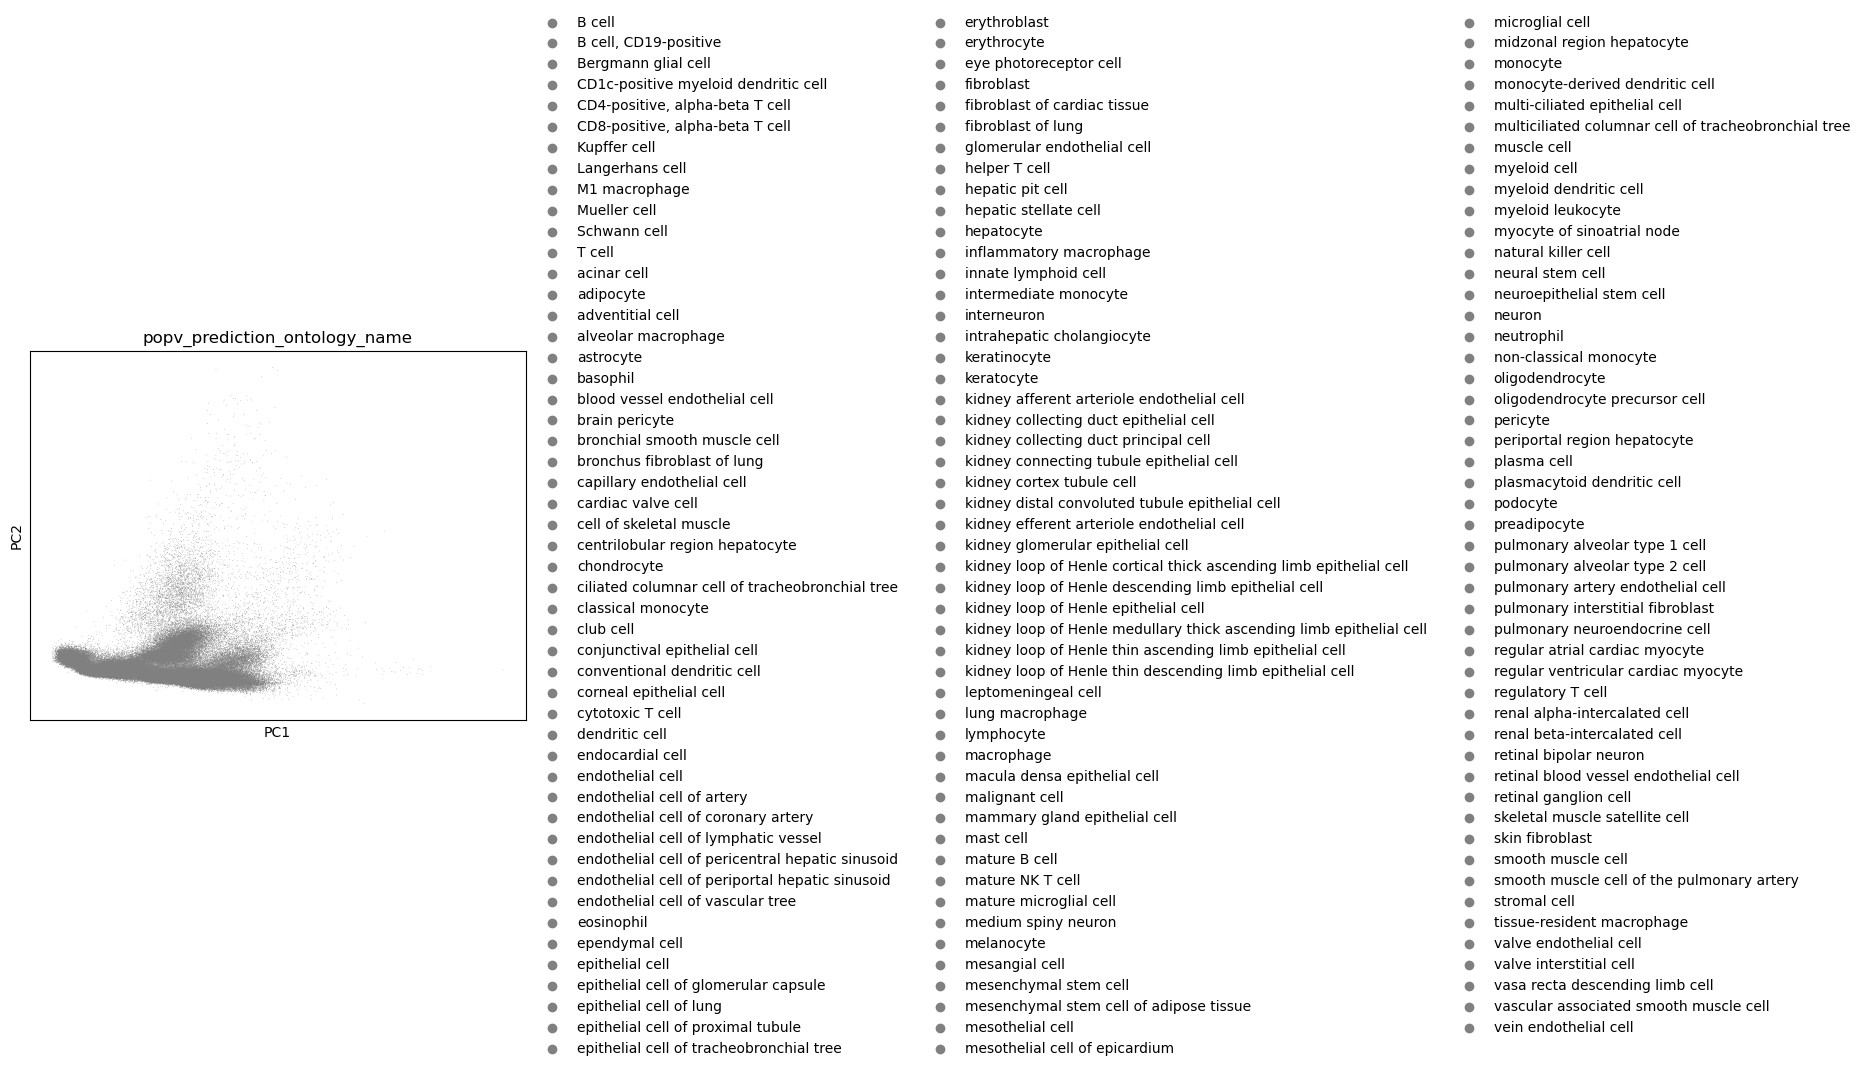

In [45]:
sc.pp.pca(combined_adata)                                               # PCA computation
sc.pl.pca(combined_adata, color="popv_prediction_ontology_name")        # Scatter plot in PCA coordinates

**UMAP plotting**

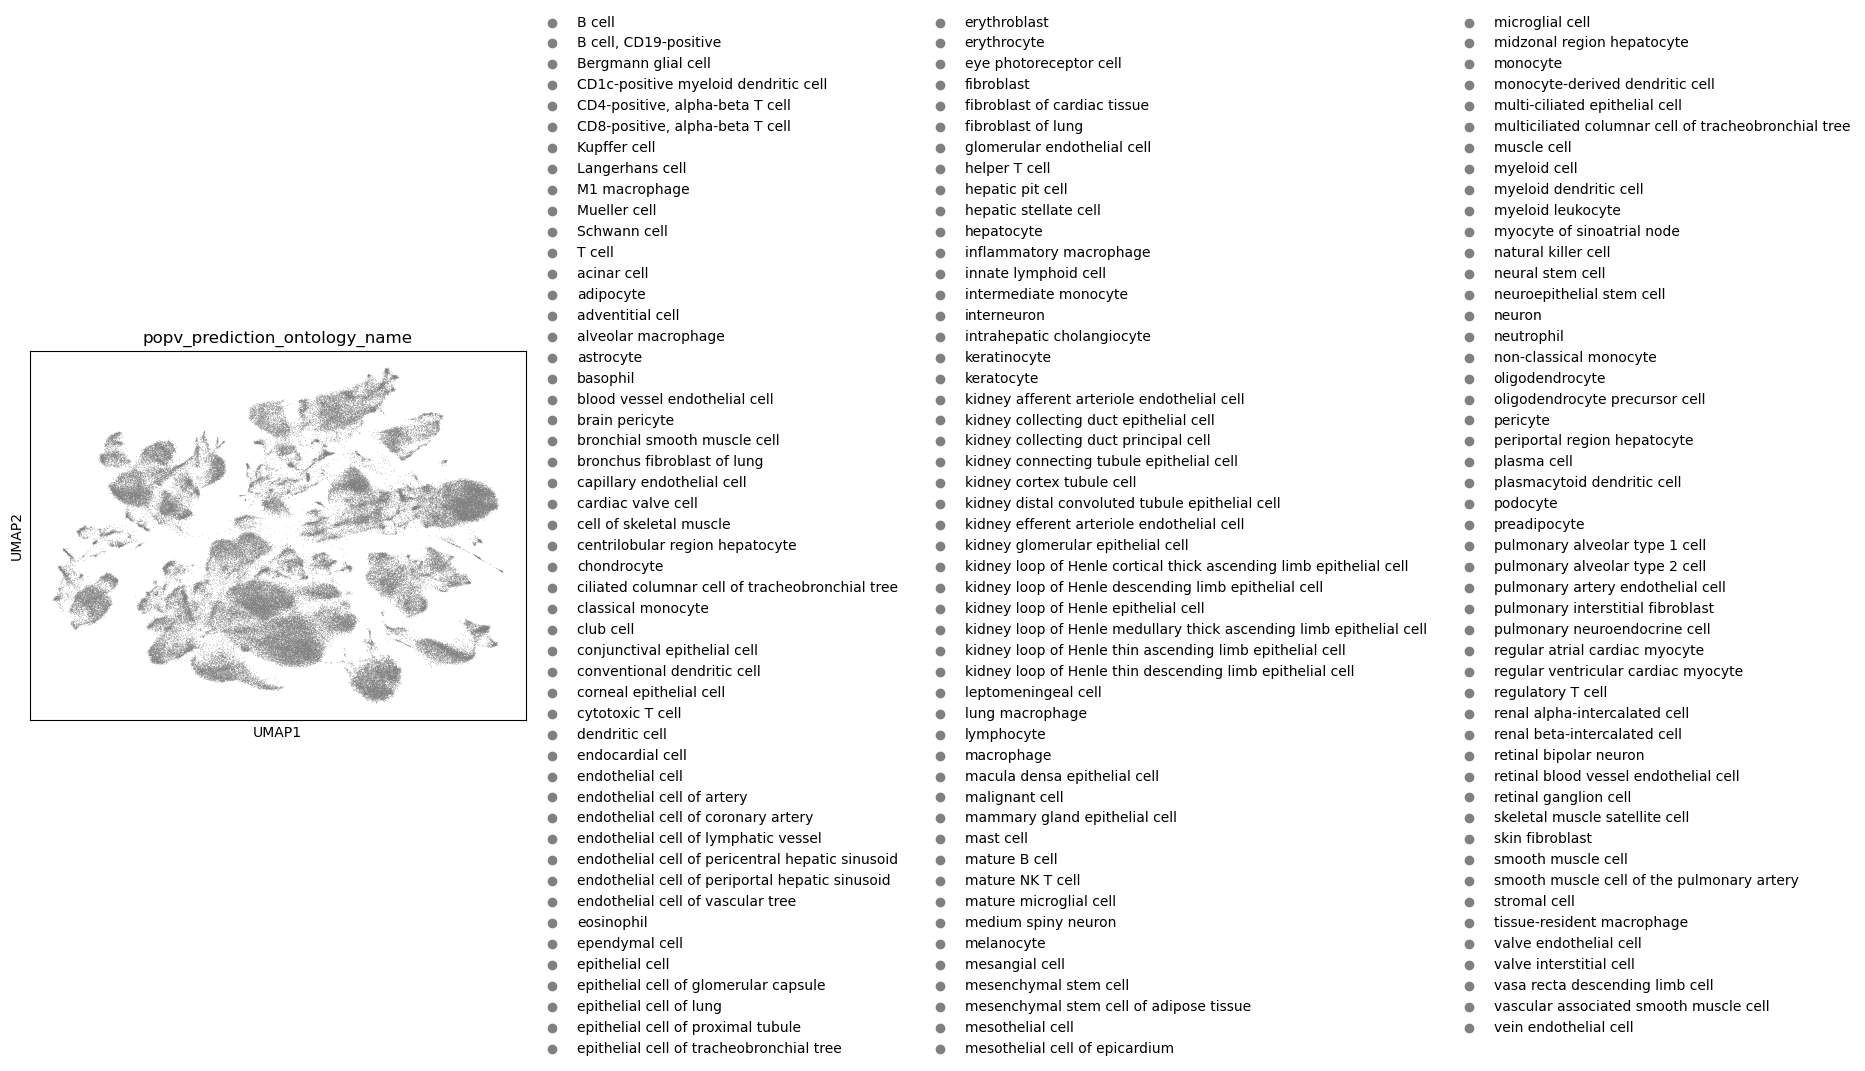

In [46]:
sc.pp.neighbors(combined_adata)
sc.tl.umap(combined_adata)
sc.pl.umap(combined_adata, color="popv_prediction_ontology_name")

In [47]:
combined_adata

AnnData object with n_obs × n_vars = 146591 × 32285
    obs: 'soma_joinid', 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_name', 'author_cell_type_cell_ontology_id', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sa

In [ ]:
sc.pp.log1p(combined_adata)                                             # Logarithmic transformation
sc.pp.highly_variable_genes(combined_adata)                             # Annotate highly variable genes
sc.pp.filter_cells(combined_adata, min_genes=3)                         # Filter out cells with less than 3 genes expressed
combined_adata

**Querying for specific type of cells (e.g., "T cell") and nFeature_RNA > 500, in the experiments in Mouse_10x collection**

Run the below cell to define the function and then execute the code in the cell below it to query for a specific cell type across all experiments in the collection and combine results into a single Anndata object.

In [2]:
def query_based_on_cell_and_gene_in_collection(collection, cell_type_to_query, gene_parameter, min_features=0):
    collection_path = "s3://rancho-scds-collections/collections/" + collection
    collection = soma.Collection.open(collection_path)
    adatas = []

    for name, expt in collection.items():
        obs_df = expt.obs.read().concat().to_pandas()
        cell_type_labels = obs_df["popv_prediction_ontology_name"][(
            obs_df["popv_prediction_ontology_name"]
            .str.contains(cell_type_to_query, na=False)
        )].unique()

        print(f'Dataset {name} \n - Cell types based on query "{cell_type_to_query}": {list(cell_type_labels)}')

        if len(cell_type_labels) > 0:

            value_filter = (
                f"popv_prediction_ontology_name in {list(cell_type_labels)} "
                f"and {gene_parameter} > {min_features}"
            )

            with expt.axis_query(
                measurement_name="RNA",
                obs_query=soma.AxisQuery(
                    value_filter=value_filter
                )
            ) as query:
                print(f' - n_obs, n_vars: {query.n_obs} cells, {query.n_vars} vars\n')
                adata = query.to_anndata(X_name="data")
                adata.obs["source_experiment"] = name
                adatas.append(adata)

    combined_adata_2 = ad.concat(adatas, join="outer", label="experiment")
    return combined_adata_2

Run the below cell to query for a specific cell type across all experiments in the collection and combine results into a single Anndata object. You can update the collection and the cell type you want to query for as needed.

In [3]:
collection = 'Mouse_10x'
cell_type_to_query = 'T cell'
gene_parameter = 'nFeature_RNA'
min_features = 500
combined_adata2 = query_based_on_cell_and_gene_in_collection(collection, cell_type_to_query, gene_parameter, min_features)
combined_adata2

Dataset batch14_GSE231924 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell']
 - n_obs, n_vars: 53 cells, 32285 vars

Dataset batch14_GSE278457 
 - Cell types based on query "T cell": []
Dataset batch15_GSE131776 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'mature NK T cell', 'T cell']
 - n_obs, n_vars: 278 cells, 32285 vars

Dataset batch15_GSE131777 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'mature NK T cell']
 - n_obs, n_vars: 43 cells, 32285 vars

Dataset batch15_GSE132420 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'T cell', 'mature NK T cell']
 - n_obs, n_vars: 5589 cells, 32285 vars

Dataset batch15_GSE155513 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'T 

/home/anne.cooley/conda/envs/tiledbsoma/lib/python3.11/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


AnnData object with n_obs × n_vars = 133237 × 32285
    obs: 'soma_joinid', 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_name', 'author_cell_type_cell_ontology_id', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sa

### Find experiments that express a particular gene

The cell-type searches above filter `obs` (cell annotations). A gene's expression is not in `obs` — it lives in the `X` matrix, indexed by `var` (the gene table). To search by gene you select it with a **`var_query`** instead of an `obs_query`, then read the counts.

The function below loops over every experiment in a collection and, for each one:

1. selects the gene on the `var` axis (`var_id` is the gene symbol; use `gene_ids` for Ensembl IDs);
2. reports whether the gene is measured at all (`n_vars == 0` means it isn't in that experiment's `var`);
3. reads the `counts` layer for that single gene and counts how many cells express it above `min_count`.

It returns a summary DataFrame across the collection.

In [5]:
def find_experiments_expressing_gene(collection, gene, min_count=0, gene_column="var_id"):
    """Report, per experiment in a collection, how many cells express `gene`."""
    collection_path = "s3://rancho-scds-collections/collections/" + collection
    rows = []

    with soma.Collection.open(collection_path) as coll:
        for name, expt in coll.items():
            with expt.axis_query(
                measurement_name="RNA",
                var_query=soma.AxisQuery(value_filter=f"{gene_column} == '{gene}'"),
            ) as query:
                if query.n_vars == 0:
                    print(f"{name}: gene '{gene}' not measured")
                    rows.append({"experiment": name, "measured": False,
                                 "n_expressing": 0, "n_cells": query.n_obs, "pct": 0.0})
                    continue

                # Long-form table of nonzero entries for this one gene: soma_data = count
                x = query.X("counts").tables().concat().to_pandas()
                n_expressing = int((x["soma_data"] > min_count).sum())
                pct = 100 * n_expressing / query.n_obs if query.n_obs else 0.0
                print(f"{name}: {n_expressing:,}/{query.n_obs:,} cells "
                      f"express {gene} (> {min_count})  [{pct:.1f}%]")
                rows.append({"experiment": name, "measured": True,
                             "n_expressing": n_expressing, "n_cells": query.n_obs,
                             "pct": round(pct, 1)})

    return pd.DataFrame(rows).sort_values("n_expressing", ascending=False).reset_index(drop=True)

Run it across a collection — e.g. `CD8A` in `Human_ss2`:

In [8]:
gene_summary = find_experiments_expressing_gene("Human_10x", gene="KISS1", min_count=0)
gene_summary

batch14_E-MTAB-10042: 0/9,766 cells express KISS1 (> 0)  [0.0%]
batch14_E-MTAB-11509: 16/25,260 cells express KISS1 (> 0)  [0.1%]
batch14_E-MTAB-9389: 93/153,538 cells express KISS1 (> 0)  [0.1%]
batch14_GSE120221: 19/127,861 cells express KISS1 (> 0)  [0.0%]
batch14_GSE155960: 11/76,588 cells express KISS1 (> 0)  [0.0%]
batch14_GSE156110: 10/26,982 cells express KISS1 (> 0)  [0.0%]
batch14_GSE166037: 246/4,886 cells express KISS1 (> 0)  [5.0%]
batch14_GSE166895: 291/90,205 cells express KISS1 (> 0)  [0.3%]
batch14_GSE185381: 413/479,636 cells express KISS1 (> 0)  [0.1%]
batch14_GSE194070: 419/52,330 cells express KISS1 (> 0)  [0.8%]
batch14_GSE196341: 227/119,991 cells express KISS1 (> 0)  [0.2%]
batch14_GSE210077: 813/197,842 cells express KISS1 (> 0)  [0.4%]
batch14_GSE210395: 3/36,491 cells express KISS1 (> 0)  [0.0%]
batch14_GSE216999: 2/114,991 cells express KISS1 (> 0)  [0.0%]
batch14_GSE224333: 10/7,945 cells express KISS1 (> 0)  [0.1%]
batch14_GSE224334: 95/64,367 cells expres

,experiment,measured,n_expressing,n_cells,pct
0,batch16_PRJNA1108254_Hs27_CRISPRa,True,51118,397431,12.9
1,batch17_GSE264667_HepG2,True,37427,454453,8.2
2,batch19_GSE231489,True,16871,24432,69.1
3,batch15_GSE266616,True,4434,378816,1.2
4,batch15_GSE168191,True,4271,170773,2.5
...,...,...,...,...,...
99,batch16_GSE263931,True,0,84511,0.0
100,batch17_GSE228127,True,0,42642,0.0
101,batch17_GSE274185,True,0,38116,0.0
102,batch18_GSE197848,True,0,25530,0.0


To pull the actual cells expressing a gene into an AnnData object (rather than just counting them), combine a `var_query` for the gene with the `obs_query`/`X` pattern used earlier — for example, restrict to a cell type *and* a gene, then `query.to_anndata(X_name="data")` per experiment and `ad.concat(...)` the results, exactly as `query_cell_type_in_collection` does.